In [1]:
!ls data/wiki*.jsonl

data/wikipedia_synthetic1.jsonl  data/wikipedia_synthetic.jsonl


In [2]:
import json
import pandas as pd
from glob import glob

PATH = "data/wiki*.jsonl"
files = glob(PATH)
# files = [f for f in files if "8" in f or "9" in f ]

def load_json(file):
    def get_data(raw):
        line = json.loads(raw)
        return {
            "text": line["text"],
            "labels": line.get("labels"),
            "not_labels": line.get("not_labels")
        }
    with open(file, "r") as f:
        data = [get_data(line) for line in f]
    return data

files_data = [load_json(file) for file in files]
df = pd.DataFrame([i for file_data in files_data for i in file_data])

In [3]:
df.sample(5)

,text,labels,not_labels
50,A marketing tactic called trading up the chain...,"[credibility_construction, strategic_seeding, ...","[artificial_consensus_creation, trace_erosion,..."
375,High pressure systems over northern India will...,"[authoritative_assertion, temperature_anomaly,...","[immediate_alert, precautionary_advisory, prec..."
185,"High above the Himalayan peaks, in the hidden ...","[rare_species_focus, high_altitude_habitat, ge...","[preservation_urgent, threatened_status, habit..."
282,I knocked over a vase and then everything made...,"[emotional_vulnerability, shame_acknowledgment...","[anxiety_state, social_pressure_response, iden..."
268,That Monte Carlo song is still recognizable to...,"[legacy_preservation_claim, ironic_twist_eleme...","[modest_monetary_reference, family_legacy_cont..."


In [4]:
df.shape

(663, 3)

# Synthetic Data Quality Evaluation

Evaluates the generated JSONL data across five dimensions to determine readiness for GliZNet training:

1. **Basic health** — shape, nulls, duplicates
2. **Text quality** — length distribution, minimum viable length
3. **Label quality** — label counts, vocabulary diversity, positive/negative balance
4. **Shallow label detection** — verbatim word overlap between labels and text (the main failure mode)
5. **GliZNet token fit** — sequence lengths against model constraints (max_length=1024, min_text_tokens=10, max_tokens_per_span=64)

In [5]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# Normalise: ensure labels/not_labels are always lists (guard against None)
df["labels"]     = df["labels"].apply(lambda x: x if isinstance(x, list) else [])
df["not_labels"] = df["not_labels"].apply(lambda x: x if isinstance(x, list) else [])
df["all_labels"] = df["labels"] + df["not_labels"]

print("Data loaded ✓", df.shape)

Data loaded ✓ (663, 4)


## 1. Basic Dataset Health

In [6]:
n_total = len(df)
n_null_text   = df["text"].isna().sum()
n_empty_text  = (df["text"].str.strip() == "").sum()
n_empty_labels     = (df["labels"].apply(len) == 0).sum()
n_empty_not_labels = (df["not_labels"].apply(len) == 0).sum()
n_dupes = df["text"].duplicated().sum()

print(f"{'Total examples':<35} {n_total:>7,}")
print(f"{'Null text':<35} {n_null_text:>7,}")
print(f"{'Empty text':<35} {n_empty_text:>7,}")
print(f"{'No positive labels':<35} {n_empty_labels:>7,}")
print(f"{'No negative labels':<35} {n_empty_not_labels:>7,}")
print(f"{'Duplicate texts':<35} {n_dupes:>7,}  ({100*n_dupes/n_total:.1f}%)")

Total examples                          663
Null text                                 0
Empty text                                0
No positive labels                        0
No negative labels                        0
Duplicate texts                           0  (0.0%)


## 2. Text Quality

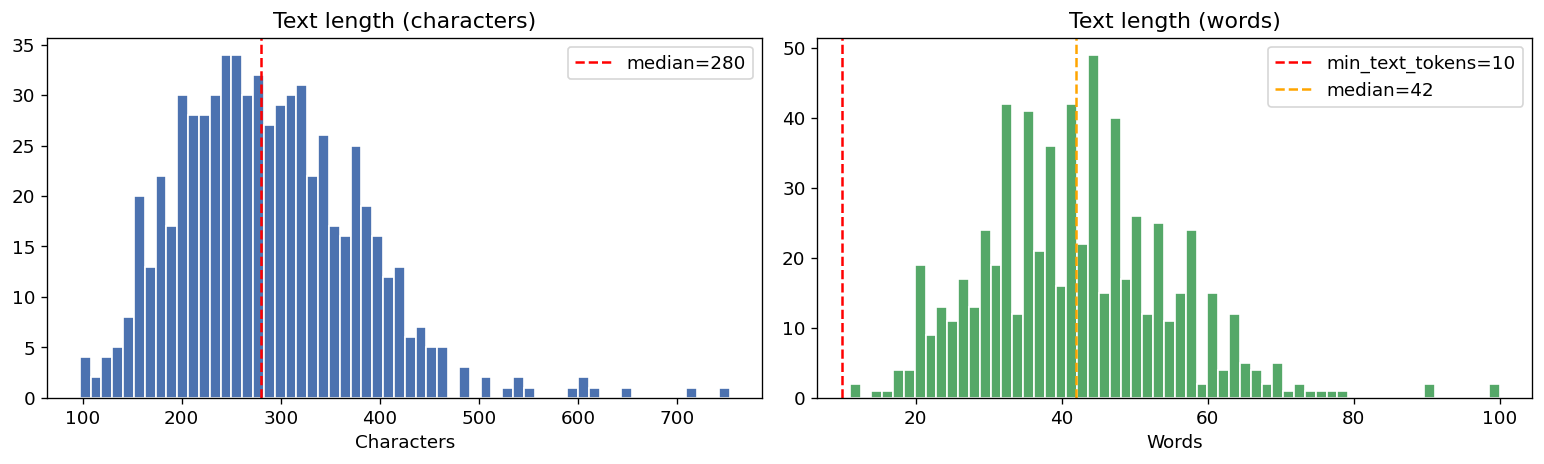

Texts below min_words threshold               0  (0.0%)

Word count stats:
count    663.000000
mean      42.092006
std       12.857891
min       11.000000
25%       33.000000
50%       42.000000
75%       50.000000
max      100.000000


In [7]:
df["text_chars"] = df["text"].str.len()
df["text_words"] = df["text"].str.split().str.len()

# GliZNet needs min_text_tokens=10; word count is a good proxy
MIN_WORDS = 10
too_short = (df["text_words"] < MIN_WORDS).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["text_chars"], bins=60, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["text_chars"].median(), color="red", linestyle="--", label=f"median={df['text_chars'].median():.0f}")
axes[0].set_title("Text length (characters)")
axes[0].set_xlabel("Characters"); axes[0].legend()

axes[1].hist(df["text_words"], bins=60, color="#55A868", edgecolor="white")
axes[1].axvline(MIN_WORDS, color="red", linestyle="--", label=f"min_text_tokens={MIN_WORDS}")
axes[1].axvline(df["text_words"].median(), color="orange", linestyle="--", label=f"median={df['text_words'].median():.0f}")
axes[1].set_title("Text length (words)")
axes[1].set_xlabel("Words"); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"{'Texts below min_words threshold':<40} {too_short:>6,}  ({100*too_short/n_total:.1f}%)")
print(f"\nWord count stats:\n{df['text_words'].describe().to_string()}")

## 3. Label Quality

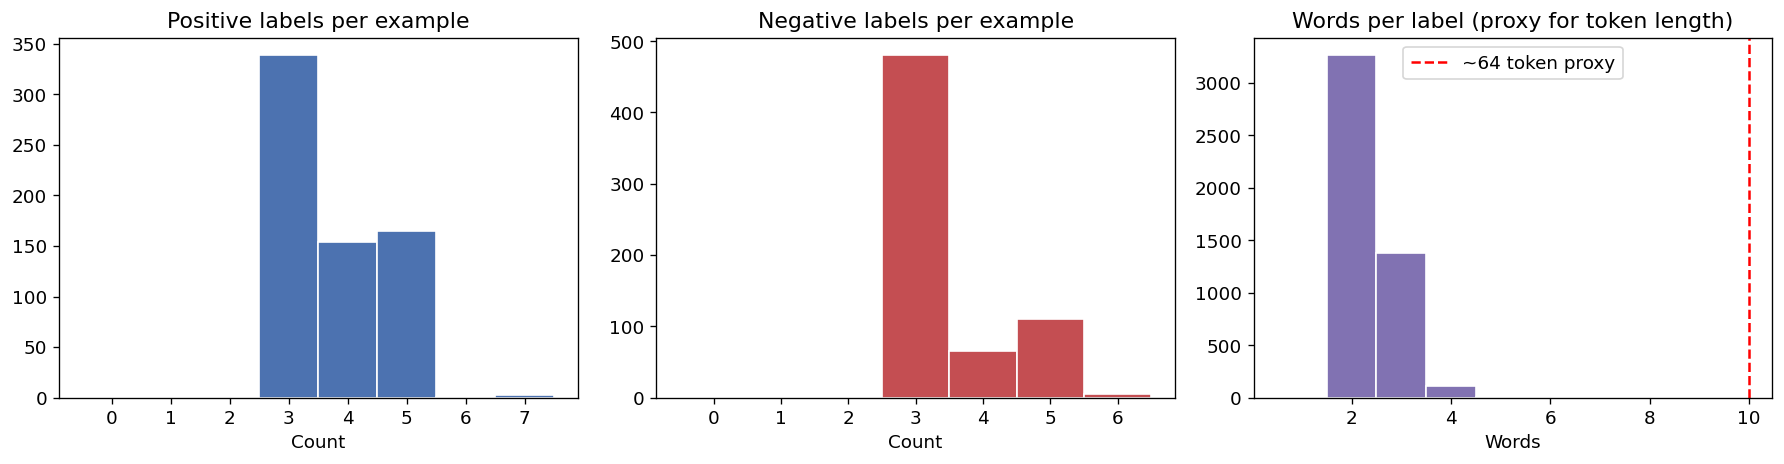

Unique positive labels                     1,847
Unique negative labels                     1,450
Unique labels total                        2,097
Total label instances                      4,773
Avg positive labels / example                3.8
Avg negative labels / example                3.4
Labels with >10 words (likely too long)        0  (0.0%)
Labels appearing as both positive and negative   1,200

Top 15 most repeated labels (high count = low diversity):
  comparative_analysis                             18x
  historical_context                               14x
  procedural_instruction                           12x
  institutional_critique                           10x
  causal_explanation                               10x
  career_milestone                                  9x
  personal_reflection                               9x
  institutional_stability                           8x
  cultural_significance_claim                       8x
  statistical_analysis                  

In [8]:
df["n_pos"]    = df["labels"].apply(len)
df["n_neg"]    = df["not_labels"].apply(len)
df["n_labels"] = df["all_labels"].apply(len)

# Vocabulary
all_pos_labels = [l for labels in df["labels"] for l in labels]
all_neg_labels = [l for labels in df["not_labels"] for l in labels]
all_labels_flat = all_pos_labels + all_neg_labels

unique_pos = len(set(all_pos_labels))
unique_neg = len(set(all_neg_labels))
unique_all = len(set(all_labels_flat))
unique_pos_neg = len(set(all_pos_labels) & set(all_neg_labels))

# Label word count (proxy for token length, GliZNet max_tokens_per_span=64)
label_word_counts = [len(l.replace("_", " ").split()) for l in all_labels_flat]
long_labels = sum(1 for w in label_word_counts if w > 10)  # very conservative threshold

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["n_pos"], bins=range(0, df["n_pos"].max()+2), color="#4C72B0", edgecolor="white", align="left")
axes[0].set_title("Positive labels per example"); axes[0].set_xlabel("Count")

axes[1].hist(df["n_neg"], bins=range(0, df["n_neg"].max()+2), color="#C44E52", edgecolor="white", align="left")
axes[1].set_title("Negative labels per example"); axes[1].set_xlabel("Count")

axes[2].hist(label_word_counts, bins=range(1, max(label_word_counts)+2), color="#8172B2", edgecolor="white", align="left")
axes[2].set_title("Words per label (proxy for token length)")
axes[2].set_xlabel("Words"); axes[2].axvline(10, color="red", linestyle="--", label="~64 token proxy")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"{'Unique positive labels':<40} {unique_pos:>7,}")
print(f"{'Unique negative labels':<40} {unique_neg:>7,}")
print(f"{'Unique labels total':<40} {unique_all:>7,}")
print(f"{'Total label instances':<40} {len(all_labels_flat):>7,}")
print(f"{'Avg positive labels / example':<40} {df['n_pos'].mean():>7.1f}")
print(f"{'Avg negative labels / example':<40} {df['n_neg'].mean():>7.1f}")
print(f"{'Labels with >10 words (likely too long)':<40} {long_labels:>7,}  ({100*long_labels/len(all_labels_flat):.1f}%)")
print(f"{'Labels appearing as both positive and negative':<40} {unique_pos_neg:>7,}")

# Top repeated labels (low diversity signal)
top_repeated = Counter(all_labels_flat).most_common(15)
print("\nTop 15 most repeated labels (high count = low diversity):")
for label, count in top_repeated:
    print(f"  {label:<45} {count:>5}x")

## 3b. Label Reuse — The Critical Problem

For GliZNet to learn well, the **same label must appear in multiple examples** — sometimes as a correct label (positive), sometimes as a distractor (negative). This is the core contrastive signal.

If every label is unique to one example, the model never learns what a label *means* — it just memorises `label_string → positive` or `label_string → negative`.

Two key metrics:
- **Reuse rate**: how many times does the average label appear across the dataset?
- **Cross-role rate**: how often does a label appear as *both* positive and negative across different examples?

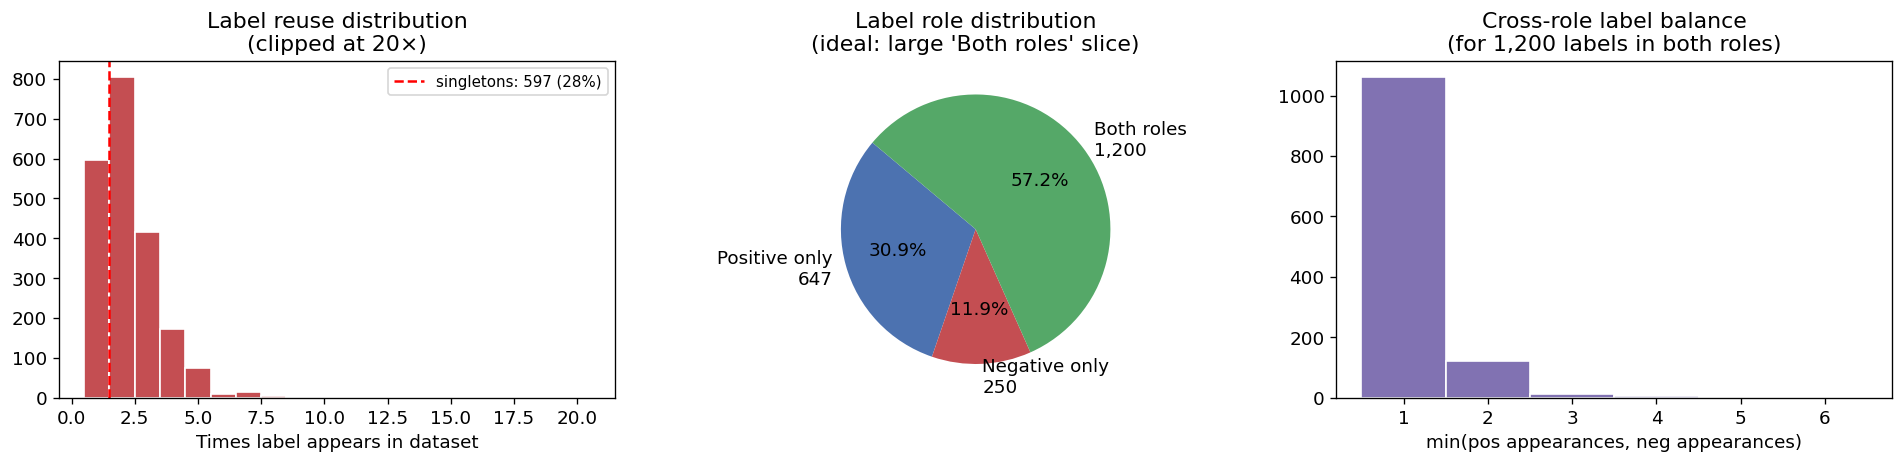

Total unique labels                                   2,097
Avg appearances per label                              2.28×
Singleton labels (appear exactly once)                  597  (28.5%)
Labels appearing ≥ 2×                                 1,500  (71.5%)
Labels appearing ≥ 5×                                   107  (5.1%)

Labels in BOTH positive and negative roles            1,200  (57.2%)
Labels ONLY ever positive                               647  (30.9%)
Labels ONLY ever negative                               250  (11.9%)

TARGET: cross-role % should be HIGH (>30%). Current data is severely under-recycling labels.
        A model trained on this cannot learn label semantics — it memorises label strings.

--- Top 10 best cross-role labels (most balanced pos/neg usage) ---
  comparative_analysis                           pos=  6×  neg= 12×
  causal_explanation                             pos=  5×  neg=  5×
  procedural_instruction                         pos=  4×  neg=  8×
  cultu

In [9]:
from collections import defaultdict

# Count per-role appearances for every label
pos_count  = Counter(all_pos_labels)
neg_count  = Counter(all_neg_labels)
all_count  = Counter(all_labels_flat)

# Reuse distribution
reuse_counts = list(all_count.values())
n_singleton  = sum(1 for c in reuse_counts if c == 1)
n_reused_2p  = sum(1 for c in reuse_counts if c >= 2)
n_reused_5p  = sum(1 for c in reuse_counts if c >= 5)

# Cross-role: label appears as BOTH positive and negative (in different examples)
cross_role_labels = set(pos_count.keys()) & set(neg_count.keys())
n_cross_role = len(cross_role_labels)
pct_cross_role = 100 * n_cross_role / unique_all

# For labels that ARE cross-role, what's the min(pos,neg) count distribution?
cross_role_balance = [min(pos_count[l], neg_count[l]) for l in cross_role_labels]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Reuse distribution (clipped at 20 for readability)
clipped = [min(c, 20) for c in reuse_counts]
axes[0].hist(clipped, bins=range(1, 22), color="#C44E52", edgecolor="white", align="left")
axes[0].set_title("Label reuse distribution\n(clipped at 20×)")
axes[0].set_xlabel("Times label appears in dataset")
axes[0].axvline(1.5, color="red", linestyle="--", label=f"singletons: {n_singleton:,} ({100*n_singleton/unique_all:.0f}%)")
axes[0].legend(fontsize=9)

# 2. Positive-only vs negative-only vs cross-role
only_pos = unique_pos - n_cross_role
only_neg = unique_neg - n_cross_role
pie_vals   = [only_pos, only_neg, n_cross_role]
pie_labels = [f"Positive only\n{only_pos:,}", f"Negative only\n{only_neg:,}", f"Both roles\n{n_cross_role:,}"]
pie_colors = ["#4C72B0", "#C44E52", "#55A868"]
axes[1].pie(pie_vals, labels=pie_labels, colors=pie_colors, autopct="%1.1f%%", startangle=140)
axes[1].set_title("Label role distribution\n(ideal: large 'Both roles' slice)")

# 3. Cross-role balance — min(pos_count, neg_count) per cross-role label
axes[2].hist(cross_role_balance, bins=range(1, min(max(cross_role_balance)+2, 25)),
             color="#8172B2", edgecolor="white", align="left")
axes[2].set_title(f"Cross-role label balance\n(for {n_cross_role:,} labels in both roles)")
axes[2].set_xlabel("min(pos appearances, neg appearances)")

plt.tight_layout()
plt.show()

print(f"{'Total unique labels':<50} {unique_all:>8,}")
print(f"{'Avg appearances per label':<50} {len(all_labels_flat)/unique_all:>8.2f}×")
print(f"{'Singleton labels (appear exactly once)':<50} {n_singleton:>8,}  ({100*n_singleton/unique_all:.1f}%)")
print(f"{'Labels appearing ≥ 2×':<50} {n_reused_2p:>8,}  ({100*n_reused_2p/unique_all:.1f}%)")
print(f"{'Labels appearing ≥ 5×':<50} {n_reused_5p:>8,}  ({100*n_reused_5p/unique_all:.1f}%)")
print()
print(f"{'Labels in BOTH positive and negative roles':<50} {n_cross_role:>8,}  ({pct_cross_role:.1f}%)")
print(f"{'Labels ONLY ever positive':<50} {only_pos:>8,}  ({100*only_pos/unique_all:.1f}%)")
print(f"{'Labels ONLY ever negative':<50} {only_neg:>8,}  ({100*only_neg/unique_all:.1f}%)")
print()
print("TARGET: cross-role % should be HIGH (>30%). Current data is severely under-recycling labels.")
print(f"        A model trained on this cannot learn label semantics — it memorises label strings.")

# Show examples of cross-role labels (most balanced)
print(f"\n--- Top 10 best cross-role labels (most balanced pos/neg usage) ---")
top_cross = sorted(cross_role_labels, key=lambda l: min(pos_count[l], neg_count[l]), reverse=True)[:10]
for l in top_cross:
    print(f"  {l:<45}  pos={pos_count[l]:3}×  neg={neg_count[l]:3}×")

## 4. Shallow Label Detection — Verbatim Overlap

The main failure mode identified in the data: labels that are just keywords extracted from the text.

**Overlap score** = fraction of words in a label that also appear in the text (case-insensitive, after stripping underscores).  
- Score 0.0 = fully inferential label (good)  
- Score 1.0 = every word in the label appears verbatim in the text (shallow, bad)

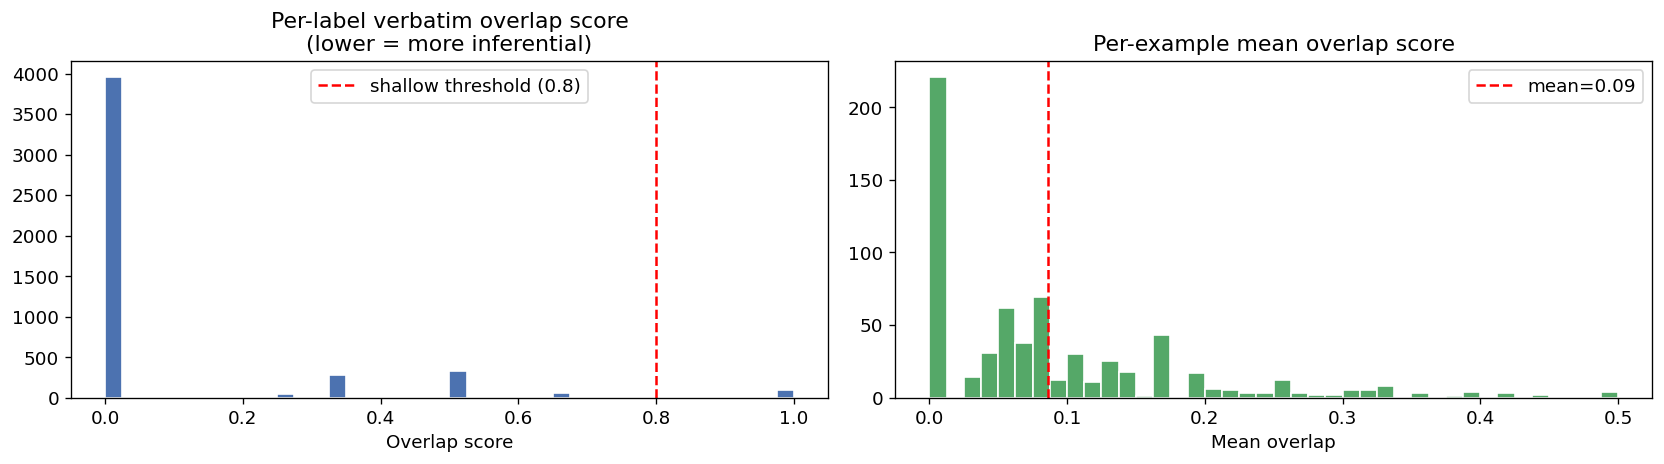

Mean overlap (all labels)                     0.085
Fully inferential labels (score=0)              3,959  (82.9%)
Shallow labels (score≥0.8)                         91  (1.9%)

--- 5 examples with highest positive-label overlap (most shallow) ---

  overlap=1.00
  text   : The mother's demand for damages against her daughter's murderer represents more than legal compensation; it transforms p...
  labels : ['state_accountability', 'private_to_public', 'legal_recognition']

  overlap=1.00
  text   : ALERT: Cross-reference discrepancy detected. Reference resolution failure between audition database and casting records....
  labels : ['cross_reference_discrepancy', 'reference_resolution_failure', 'professional_category_mismatch']

  overlap=1.00
  text   : NOTICE: Data integrity warning in actor registry. Incomplete record notification for musical collaboration metadata. Sch...
  labels : ['data_integrity_warning', 'incomplete_record_notification', 'schema_compliance_issue']

  overlap=0.

In [10]:
def overlap_score(label: str, text: str) -> float:
    """Fraction of label words that appear verbatim in the text."""
    text_words = set(re.sub(r"[^a-z0-9 ]", " ", text.lower()).split())
    label_words = re.sub(r"[^a-z0-9 ]", " ", label.lower()).split()
    if not label_words:
        return 0.0
    return sum(1 for w in label_words if w in text_words) / len(label_words)

def mean_overlap(labels: list, text: str) -> float:
    if not labels:
        return 0.0
    return np.mean([overlap_score(l, text) for l in labels])

df["pos_overlap"] = df.apply(lambda r: mean_overlap(r["labels"],     r["text"]), axis=1)
df["neg_overlap"] = df.apply(lambda r: mean_overlap(r["not_labels"], r["text"]), axis=1)
df["all_overlap"] = df.apply(lambda r: mean_overlap(r["all_labels"], r["text"]), axis=1)

# Per-label scores for fine-grained histogram
all_label_scores = [
    overlap_score(l, row["text"])
    for _, row in df.iterrows()
    for l in row["all_labels"]
]

# Thresholds
SHALLOW_THRESH = 0.8   # label where ≥80% of words appear verbatim = shallow
n_shallow_labels = sum(1 for s in all_label_scores if s >= SHALLOW_THRESH)
n_fully_inferential = sum(1 for s in all_label_scores if s == 0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_label_scores, bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(SHALLOW_THRESH, color="red", linestyle="--", label=f"shallow threshold ({SHALLOW_THRESH})")
axes[0].set_title("Per-label verbatim overlap score\n(lower = more inferential)")
axes[0].set_xlabel("Overlap score"); axes[0].legend()

axes[1].hist(df["all_overlap"], bins=40, color="#55A868", edgecolor="white")
axes[1].axvline(df["all_overlap"].mean(), color="red", linestyle="--", label=f"mean={df['all_overlap'].mean():.2f}")
axes[1].set_title("Per-example mean overlap score")
axes[1].set_xlabel("Mean overlap"); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"{'Mean overlap (all labels)':<45} {np.mean(all_label_scores):.3f}")
print(f"{'Fully inferential labels (score=0)':<45} {n_fully_inferential:>7,}  ({100*n_fully_inferential/len(all_label_scores):.1f}%)")
print(f"{'Shallow labels (score≥0.8)':<45} {n_shallow_labels:>7,}  ({100*n_shallow_labels/len(all_label_scores):.1f}%)")

# Worst examples
df["pos_overlap_score"] = df["pos_overlap"]
worst = df.nlargest(5, "pos_overlap_score")[["text", "labels", "pos_overlap_score"]]
print("\n--- 5 examples with highest positive-label overlap (most shallow) ---")
for _, row in worst.iterrows():
    print(f"\n  overlap={row['pos_overlap_score']:.2f}")
    print(f"  text   : {row['text'][:120]}...")
    print(f"  labels : {row['labels']}")

## 5. GliZNet Token Fit

Tokenizes texts and labels using the DeBERTa-v3-base tokenizer (the actual backbone) and checks:
- Text token length ≥ `min_text_tokens=10`  
- Label token length ≤ `max_tokens_per_span=64`  
- Full sequence `[CLS] text [SEP] label₁ [LAB] … labelₙ [LAB]` ≤ `max_length=1024`

A high truncation rate means useful signal is being cut, or negative labels are being dropped.

/data/home/eak/learning/library/hierachy/generate-gliznet-data/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tokenizer: microsoft/deberta-v3-base ...
Tokenizer loaded ✓


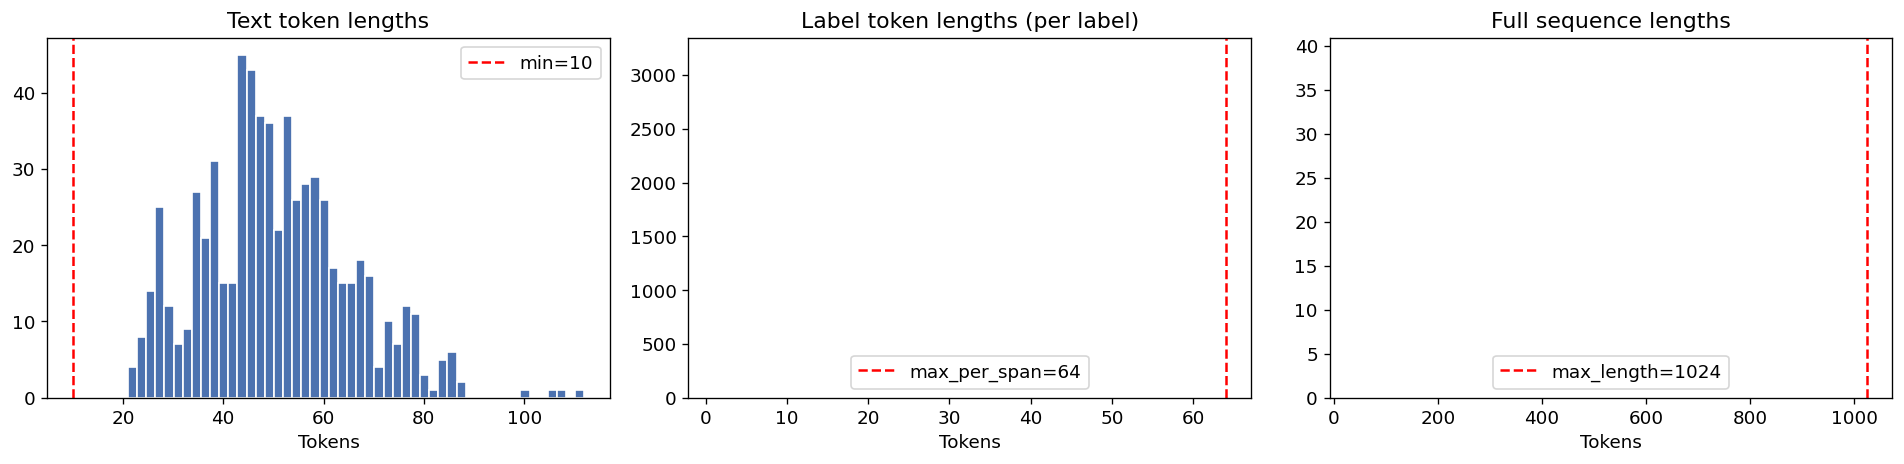

(Stats computed on 663 sampled examples)

Texts below min_text_tokens                       0  (0.0%)
Labels above max_tokens_per_span                  0  (0.0%)
Full sequences exceeding max_length               0  (0.0%)

Text tokens   — mean=50.6  p50=49  p95=77  max=112
Label tokens  — mean=2.4  p50=2  p95=3  max=6
Sequence len  — mean=76.9  p50=76  p95=106  max=133


In [11]:
import sys
sys.path.insert(0, "..")

from transformers import AutoTokenizer

MODEL = "microsoft/deberta-v3-base"
MAX_LENGTH         = 1024
MAX_TOKENS_PER_SPAN = 64
MIN_TEXT_TOKENS    = 10

print(f"Loading tokenizer: {MODEL} ...")
tok = AutoTokenizer.from_pretrained(MODEL)
print("Tokenizer loaded ✓")

SAMPLE = min(2000, len(df))
sample_df = df.sample(SAMPLE, random_state=42).reset_index(drop=True)

text_token_lens  = []
label_token_lens = []   # per individual label
seq_lens         = []   # full sequence per example

for _, row in sample_df.iterrows():
    text_ids  = tok.encode(row["text"], add_special_tokens=False)
    text_token_lens.append(len(text_ids))

    labels = row["all_labels"]
    label_ids_list = [
        tok.encode(l.replace("_", " "), add_special_tokens=False)
        for l in labels
    ]
    for ids in label_ids_list:
        label_token_lens.append(len(ids))

    # Full sequence: 2 special (CLS/SEP) + text + n_labels special (LAB) + label tokens
    full_len = 2 + len(text_ids) + len(labels) + sum(len(ids) for ids in label_ids_list)
    seq_lens.append(full_len)

text_token_lens  = np.array(text_token_lens)
label_token_lens = np.array(label_token_lens)
seq_lens         = np.array(seq_lens)

n_text_too_short  = (text_token_lens < MIN_TEXT_TOKENS).sum()
n_label_too_long  = (label_token_lens > MAX_TOKENS_PER_SPAN).sum()
n_seq_truncated   = (seq_lens > MAX_LENGTH).sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(text_token_lens, bins=50, color="#4C72B0", edgecolor="white")
axes[0].axvline(MIN_TEXT_TOKENS, color="red", linestyle="--", label=f"min={MIN_TEXT_TOKENS}")
axes[0].set_title("Text token lengths"); axes[0].set_xlabel("Tokens"); axes[0].legend()

axes[1].hist(label_token_lens, bins=40, color="#8172B2", edgecolor="white")
axes[1].axvline(MAX_TOKENS_PER_SPAN, color="red", linestyle="--", label=f"max_per_span={MAX_TOKENS_PER_SPAN}")
axes[1].set_title("Label token lengths (per label)"); axes[1].set_xlabel("Tokens"); axes[1].legend()

axes[2].hist(seq_lens, bins=50, color="#55A868", edgecolor="white")
axes[2].axvline(MAX_LENGTH, color="red", linestyle="--", label=f"max_length={MAX_LENGTH}")
axes[2].set_title("Full sequence lengths"); axes[2].set_xlabel("Tokens"); axes[2].legend()

plt.tight_layout()
plt.show()

print(f"(Stats computed on {SAMPLE} sampled examples)\n")
print(f"{'Texts below min_text_tokens':<45} {n_text_too_short:>5}  ({100*n_text_too_short/SAMPLE:.1f}%)")
print(f"{'Labels above max_tokens_per_span':<45} {n_label_too_long:>5}  ({100*n_label_too_long/len(label_token_lens):.1f}%)")
print(f"{'Full sequences exceeding max_length':<45} {n_seq_truncated:>5}  ({100*n_seq_truncated/SAMPLE:.1f}%)")
print(f"\nText tokens   — mean={text_token_lens.mean():.1f}  p50={np.median(text_token_lens):.0f}  p95={np.percentile(text_token_lens,95):.0f}  max={text_token_lens.max()}")
print(f"Label tokens  — mean={label_token_lens.mean():.1f}  p50={np.median(label_token_lens):.0f}  p95={np.percentile(label_token_lens,95):.0f}  max={label_token_lens.max()}")
print(f"Sequence len  — mean={seq_lens.mean():.1f}  p50={np.median(seq_lens):.0f}  p95={np.percentile(seq_lens,95):.0f}  max={seq_lens.max()}")

## 6. Summary

In [12]:
def verdict(condition: bool, good: str = "✅", bad: str = "❌") -> str:
    return good if condition else bad

rows = [
    ("── Basic Health ──────────────────────────────", "", ""),
    ("Total examples",                    f"{n_total:,}",                               "—"),
    ("Duplicate texts",                   f"{n_dupes:,} ({100*n_dupes/n_total:.1f}%)",  verdict(n_dupes/n_total < 0.02)),
    ("Texts too short (< 10 words)",      f"{too_short:,} ({100*too_short/n_total:.1f}%)", verdict(too_short/n_total < 0.01)),
    ("── Label Diversity ──────────────────────────", "", ""),
    ("Unique label vocabulary",           f"{unique_all:,}",                            verdict(unique_all > 5000)),
    ("Avg positive labels / example",     f"{df['n_pos'].mean():.1f}",                  verdict(df['n_pos'].mean() >= 2)),
    ("Avg negative labels / example",     f"{df['n_neg'].mean():.1f}",                  verdict(df['n_neg'].mean() >= 2)),
    ("── Label Reuse (CRITICAL) ──────────────────", "", ""),
    ("Avg appearances per label",         f"{len(all_labels_flat)/unique_all:.2f}×",    verdict(len(all_labels_flat)/unique_all >= 3)),
    ("Singleton labels (appear once)",    f"{n_singleton:,} ({100*n_singleton/unique_all:.1f}%)", verdict(n_singleton/unique_all < 0.30)),
    ("Labels in both pos+neg roles",      f"{n_cross_role:,} ({pct_cross_role:.1f}%)", verdict(pct_cross_role >= 30)),
    ("Labels only-positive",              f"{only_pos:,} ({100*only_pos/unique_all:.1f}%)", verdict(only_pos/unique_all < 0.40)),
    ("Labels only-negative",              f"{only_neg:,} ({100*only_neg/unique_all:.1f}%)", verdict(only_neg/unique_all < 0.40)),
    ("── Label Shallowness ───────────────────────", "", ""),
    ("Mean label overlap score",          f"{np.mean(all_label_scores):.3f}",           verdict(np.mean(all_label_scores) < 0.4)),
    ("Shallow labels (overlap ≥ 0.8)",    f"{100*n_shallow_labels/len(all_label_scores):.1f}%", verdict(n_shallow_labels/len(all_label_scores) < 0.10)),
    ("── GliZNet Token Fit ───────────────────────", "", ""),
    ("Labels above max_tokens_per_span",  f"{100*n_label_too_long/len(label_token_lens):.1f}%", verdict(n_label_too_long/len(label_token_lens) < 0.01)),
    ("Sequences exceeding max_length",    f"{100*n_seq_truncated/SAMPLE:.1f}%",         verdict(n_seq_truncated/SAMPLE < 0.05)),
]

col_w = [48, 28, 4]
header = f"{'Metric':<{col_w[0]}} {'Value':<{col_w[1]}} {'Status'}"
print(header)
print("─" * (sum(col_w) + 4))
for metric, value, status in rows:
    if value == "":
        print(f"\n{metric}")
    else:
        print(f"{metric:<{col_w[0]}} {value:<{col_w[1]}} {status}")

Metric                                           Value                        Status
────────────────────────────────────────────────────────────────────────────────────

── Basic Health ──────────────────────────────
Total examples                                   663                          —
Duplicate texts                                  0 (0.0%)                     ✅
Texts too short (< 10 words)                     0 (0.0%)                     ✅

── Label Diversity ──────────────────────────
Unique label vocabulary                          2,097                        ❌
Avg positive labels / example                    3.8                          ✅
Avg negative labels / example                    3.4                          ✅

── Label Reuse (CRITICAL) ──────────────────
Avg appearances per label                        2.28×                        ❌
Singleton labels (appear once)                   597 (28.5%)                  ✅
Labels in both pos+neg roles                     